# Эксперименты: сравнение моделей

Модели и их параметры — те же, что в первой версии проекта: логистическая регрессия, Random Forest, CatBoost и нейросеть `Neiro` на PyTorch.

Изменились только условия сравнения — теперь они одинаковые для всех:

- одни и те же данные (`X_train_val`, 80%) — тестовая выборка здесь **не используется**;
- одни и те же 5 фолдов кросс-валидации;
- одна и та же подготовка признаков (`src/features.py`);
- одни и те же метрики: PR-AUC, ROC-AUC и F1 при лучшем пороге.

Для каждой модели считаем **out-of-fold** вероятности: каждый клиент получает прогноз от модели, которая его не видела.

In [1]:
import sys; sys.path.append('..')
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier

from src.features import add_features, CAT_COLS, NUM_COLS

## Данные

In [2]:
df = pd.read_csv('../Dataset.csv')
X = df.drop(columns='Churn')
y = (df['Churn'] == 'Yes').astype(int)

# тот же split, что в notebook.ipynb — тест откладываем и не трогаем
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
features = FunctionTransformer(add_features)

# кодирование для LR и нейросети: one-hot для категорий, масштабирование чисел
prep_scaled = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
])

## Функция оценки

Для каждой модели:
1. получаем out-of-fold вероятности;
2. считаем PR-AUC и ROC-AUC (не зависят от порога);
3. подбираем порог с максимальным F1.

In [3]:
def evaluate(model, X, y):
    start = time.time()
    proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

    precision, recall, thresholds = precision_recall_curve(y, proba)
    precision, recall = precision[:-1], recall[:-1]
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    best_i = np.argmax(f1)

    metrics = {
        'PR-AUC': average_precision_score(y, proba),
        'ROC-AUC': roc_auc_score(y, proba),
        'F1': f1[best_i],
        'Порог': thresholds[best_i],
        'Recall': recall[best_i],
        'Precision': precision[best_i],
        'Время, с': time.time() - start,
    }
    return metrics, proba

## Модели

### 1. Логистическая регрессия

In [4]:
lr_pipe = Pipeline([
    ('features', features),
    ('prep', prep_scaled),
    ('model', LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')),
])

### 2. Random Forest
Деревьям масштабирование не нужно — числовые признаки передаём как есть (`passthrough`).

In [5]:
rf_pipe = Pipeline([
    ('features', features),
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
        ('num', 'passthrough', NUM_COLS),
    ])),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42)),
])

### 3. CatBoost
`class_weights` передаём кортежем (`tuple`), а не списком — иначе sklearn не сможет скопировать модель для кросс-валидации.

In [6]:
ratio = y_train_val.value_counts()[0] / y_train_val.value_counts()[1]

cb_pipe = Pipeline([
    ('features', features),
    ('model', CatBoostClassifier(
        iterations=100,
        depth=7,
        learning_rate=0.1,
        cat_features=tuple(CAT_COLS),
        class_weights=(1, ratio),
        random_seed=42,
        verbose=False,
    )),
])

### 4. Нейросеть `Neiro` (PyTorch)

Архитектура, функции обучения и параметры — из первой версии: Adam (lr=0.001), `CrossEntropyLoss` с весами классов, батч 64, 300 эпох.

Два отличия:
- число входов берётся из данных (`n_inputs`), а не задано числом 22 — признаков после one-hot теперь больше;
- сеть обёрнута в класс `NeiroClassifier` с методами `fit` / `predict_proba`, чтобы её можно было оценивать той же кросс-валидацией, что и остальные модели.

In [7]:
class Neiro(nn.Module):
  def __init__(self, n_inputs):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(n_inputs,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64,32),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.Linear(32,2)
    )
  def forward(self,x):
    return self.net(x)

In [8]:
class ChurnDataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(np.asarray(x), dtype=torch.float32)
    self.y=torch.tensor(np.asarray(y), dtype=torch.long)
  def __len__(self):
    return len(self.y)
  def __getitem__(self, index):
    return self.x[index],self.y[index]


def train_step(model,optimizer,criterion,batch,device):
  X,y=batch
  X=X.to(device)
  y=y.to(device)

  model.train()
  optimizer.zero_grad()
  pred=model(X)
  loss=criterion(pred,y)
  loss.backward()
  optimizer.step()

  return loss.item()


def train_epoch(model,optimizer,criterion,device,train_loader):
  model.train()
  loss=0.0
  for batch in train_loader:
    loss_step=train_step(model,optimizer,criterion,batch,device)
    loss+=loss_step
  return loss/len(train_loader)


def val_loss(model,criterion,device,X,y):
  model.eval()
  with torch.no_grad():
    pred=model(torch.tensor(np.asarray(X), dtype=torch.float32).to(device))
    loss=criterion(pred, torch.tensor(np.asarray(y), dtype=torch.long).to(device))
  return loss.item()

In [9]:
class NeiroClassifier(ClassifierMixin, BaseEstimator):
  def __init__(self, epochs=300, batch_size=64, lr=0.001, random_state=42):
    self.epochs=epochs
    self.batch_size=batch_size
    self.lr=lr
    self.random_state=random_state

  def fit(self, X, y, X_val=None, y_val=None):
    torch.manual_seed(self.random_state)
    self.classes_=np.array([0, 1])
    self.device_=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    y=np.asarray(y)

    train_loader=DataLoader(ChurnDataset(X,y), batch_size=self.batch_size, shuffle=False)

    weight_for_1=len(y)/(2*np.bincount(y)[1])
    weight_for_0=len(y)/(2*np.bincount(y)[0])
    class_weights=torch.tensor([weight_for_0, weight_for_1], dtype=torch.float32).to(self.device_)

    self.model_=Neiro(np.asarray(X).shape[1]).to(self.device_)
    optimizer=optim.Adam(self.model_.parameters(), lr=self.lr)
    criterion=nn.CrossEntropyLoss(weight=class_weights)

    # история loss; val — только если передали валидационные данные
    self.metrics_={'train_loss':[], 'val_loss':[]}
    for epoch in range(self.epochs):
      self.metrics_['train_loss'].append(train_epoch(self.model_,optimizer,criterion,self.device_,train_loader))
      if X_val is not None:
        self.metrics_['val_loss'].append(val_loss(self.model_,criterion,self.device_,X_val,y_val))
    return self

  def predict_proba(self, X):
    self.model_.eval()
    with torch.no_grad():
      logits=self.model_(torch.tensor(np.asarray(X), dtype=torch.float32).to(self.device_))
      proba=torch.softmax(logits, dim=1).cpu().numpy()
    return proba

  def predict(self, X):
    return self.predict_proba(X).argmax(axis=1)

In [10]:
nn_pipe = Pipeline([
    ('features', features),
    ('prep', prep_scaled),
    ('model', NeiroClassifier()),
])

Кривые обучения: обучаем сеть один раз на части `X_train_val` и следим за loss на отложенной части — как в первой версии.

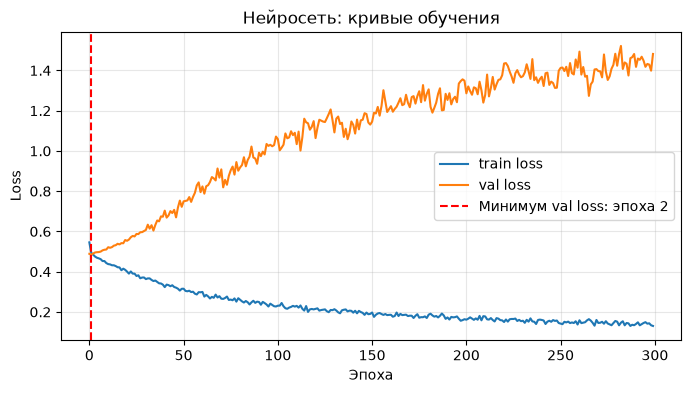

In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=42)

prep =ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
]).fit(add_features(X_tr))

net = NeiroClassifier().fit(prep.transform(add_features(X_tr)), y_tr,
                            prep.transform(add_features(X_val)), y_val)

best_epoch = int(np.argmin(net.metrics_['val_loss'])) + 1
plt.figure(figsize=(8, 4))
plt.plot(net.metrics_['train_loss'], label='train loss')
plt.plot(net.metrics_['val_loss'], label='val loss')
plt.axvline(best_epoch - 1, color='red', linestyle='--', label=f'Минимум val loss: эпоха {best_epoch}')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Нейросеть: кривые обучения')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Сравнение

In [12]:
models = {
    'Logistic Regression': lr_pipe,
    'Random Forest': rf_pipe,
    'CatBoost': cb_pipe,
    'Neural Network': nn_pipe,
}

results, oof = {}, {}
for name, model in models.items():
    results[name], oof[name] = evaluate(model, X_train_val, y_train_val)
    print(f'{name}: готово за {results[name]["Время, с"]:.0f} с')

df_results = pd.DataFrame(results).T.sort_values('PR-AUC', ascending=False)
df_results.round(3)

Logistic Regression: готово за 0 с


Random Forest: готово за 5 с


CatBoost: готово за 3 с


Neural Network: готово за 132 с


,PR-AUC,ROC-AUC,F1,Порог,Recall,Precision,"Время, с"
CatBoost,0.659,0.845,0.640,0.561,0.730,0.569,2.695
Logistic Regression,0.658,0.847,0.638,0.583,0.728,0.568,0.370
Random Forest,0.621,0.827,0.616,0.316,0.724,0.536,5.065
Neural Network,0.527,0.783,0.572,0.103,0.746,0.464,132.192


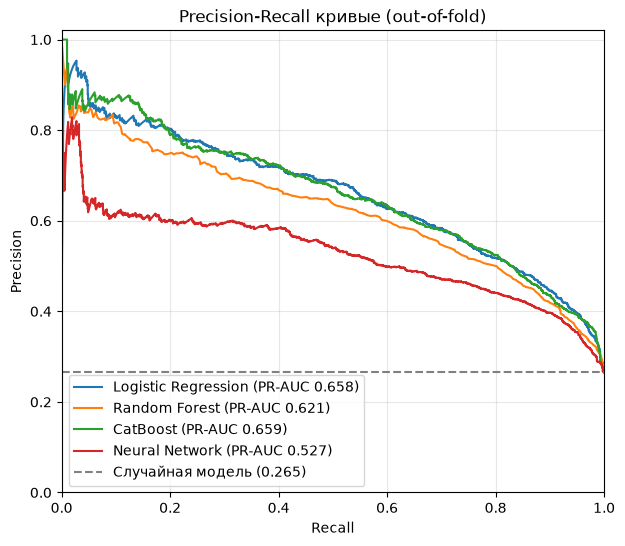

In [ ]:
baseline = y_train_val.mean()

fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in oof.items():
    precision, recall, _ = precision_recall_curve(y_train_val, proba)
    ax.plot(recall, precision, label=f'{name} (PR-AUC {results[name]["PR-AUC"]:.3f})')
ax.axhline(baseline, color='gray', linestyle='--', label=f'Случайная модель ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривые (out-of-fold)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(loc='lower left')
plt.show()

## Выводы

| Модель | PR-AUC | ROC-AUC | F1 |
|---|---|---|---|
| CatBoost | 0.659 | 0.845 | 0.640 |
| Logistic Regression | 0.658 | 0.847 | 0.638 |
| Random Forest | 0.621 | 0.827 | 0.616 |
| Neural Network | 0.527 | 0.783 | 0.572 |

- **CatBoost и логистическая регрессия практически равны** (разница по PR-AUC 0.001 — это шум). Обе заметно лучше Random Forest и нейросети.
- **Random Forest** с параметрами по умолчанию растит деревья до конца и запоминает обучающие данные — ему не хватает ограничений (`min_samples_leaf`, `max_depth`).
- **Нейросеть сильно переобучается**: val loss минимален уже на 2-й эпохе, а дальше растёт до ~1.4, пока train loss падает. После 300 эпох она уверенно ошибается, поэтому и метрики самые низкие.
- Пороги у LR и CatBoost получились высокими (~0.56–0.58): веса классов (`class_weight='balanced'`, `class_weights`) завышают вероятности ухода. На качество ранжирования (PR-AUC) это не влияет.

**Итог:** дальше работаем с CatBoost в `notebook.ipynb` подбираем его параметры через GridSearch, выбираем порог и проверяем на тесте
